In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("Data\\loan_data.csv")

In [7]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [8]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [9]:
df.shape

(45000, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [11]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [12]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

Categorical Columns:
Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')


In [16]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64

person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


In [17]:
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]
categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

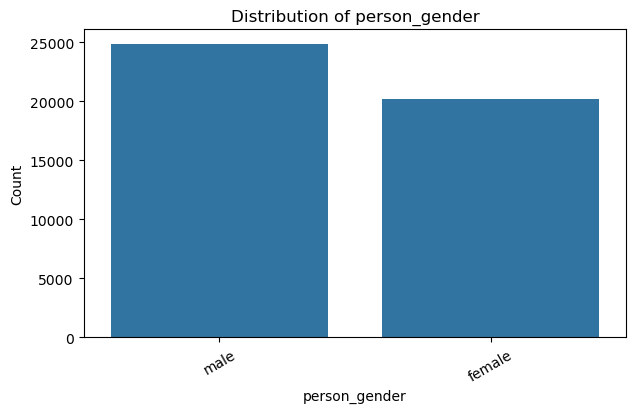

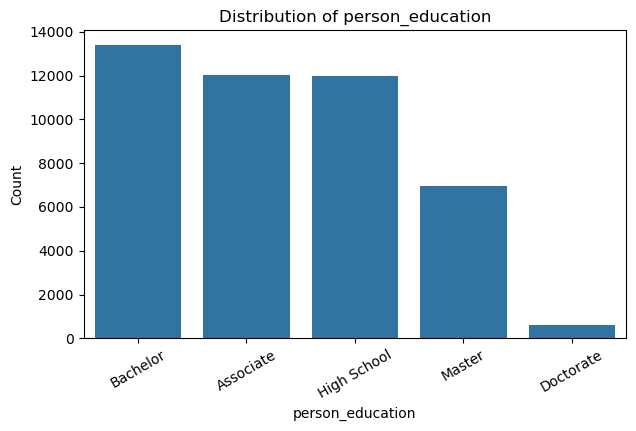

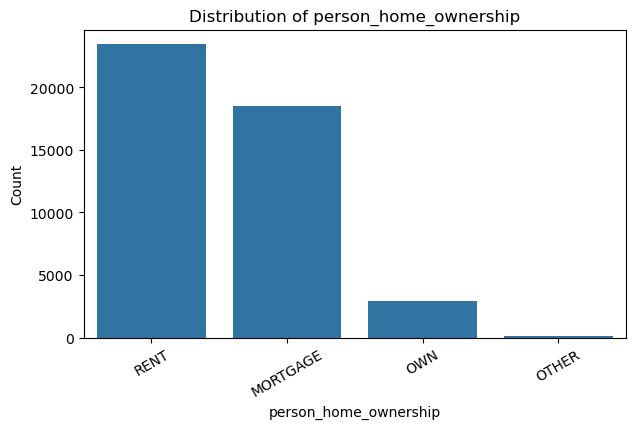

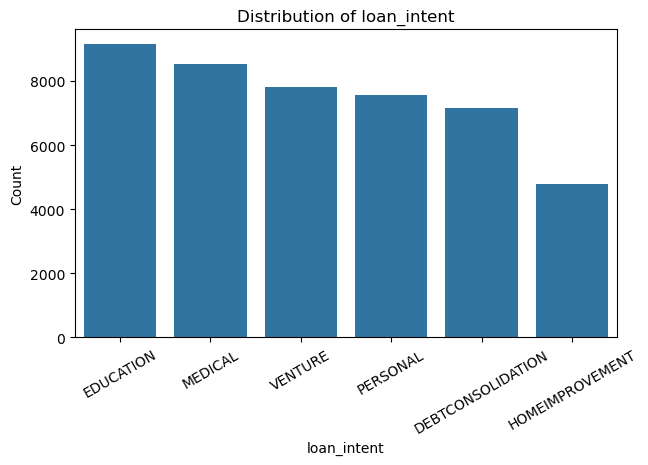

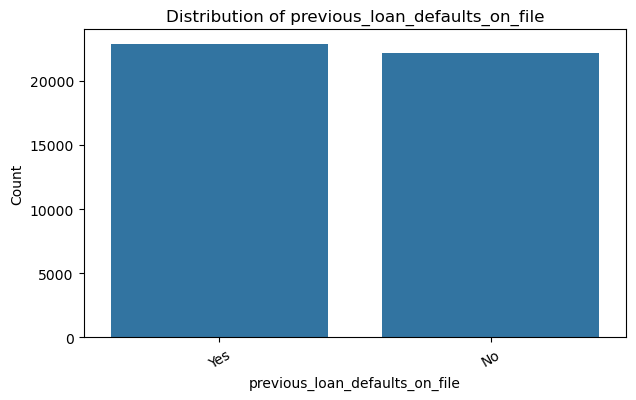

In [18]:
for column in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=30)

    plt.show()

In [19]:
df["loan_status"].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [20]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

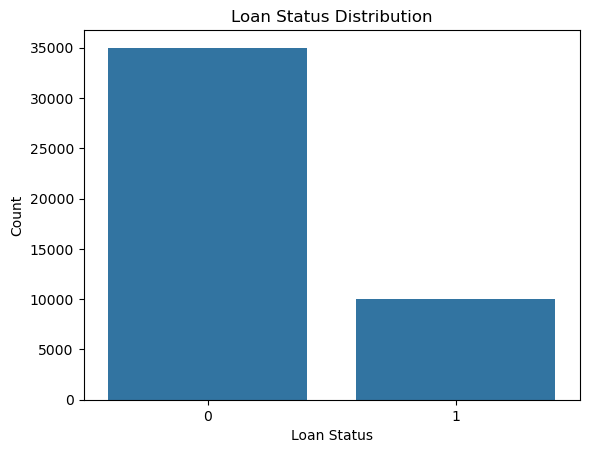

In [21]:
sns.countplot(data=df, x="loan_status")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

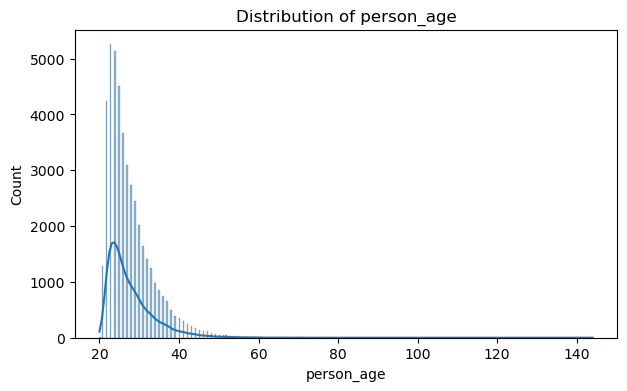

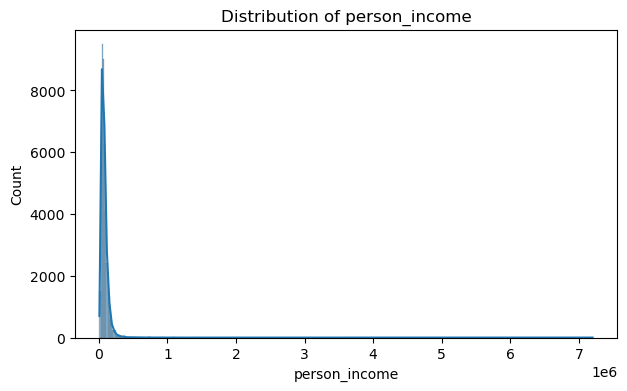

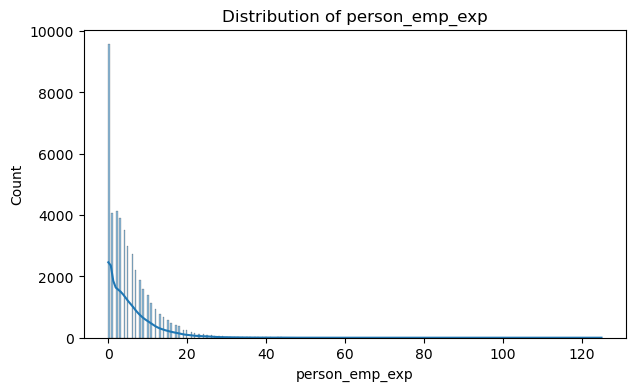

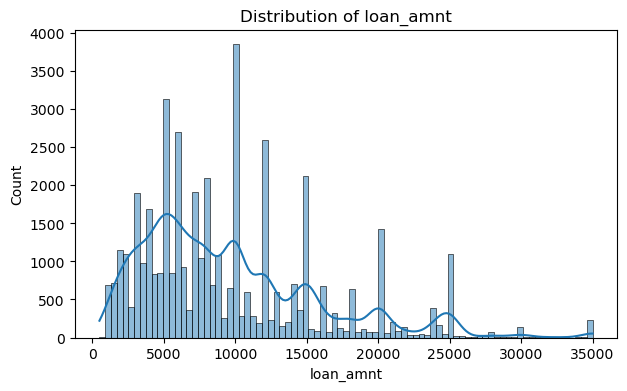

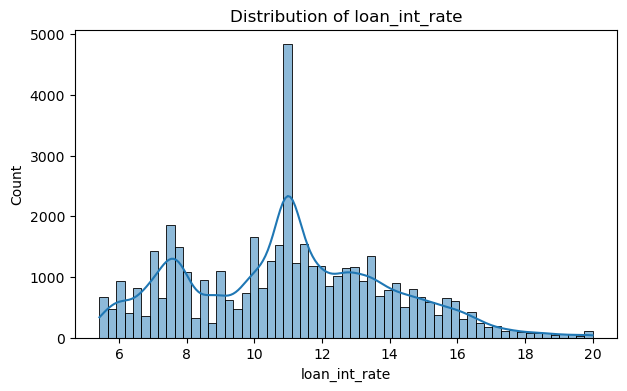

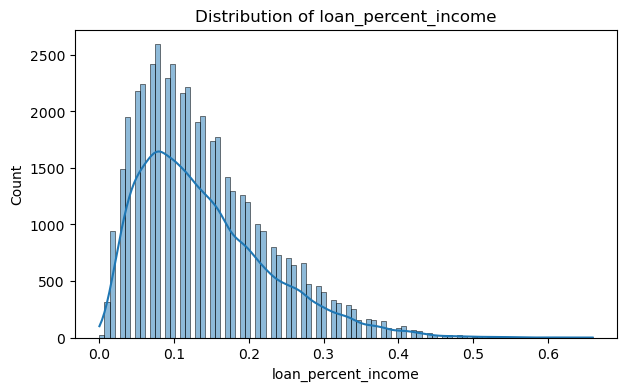

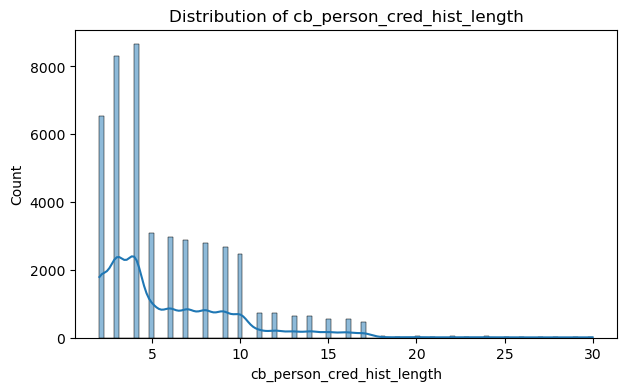

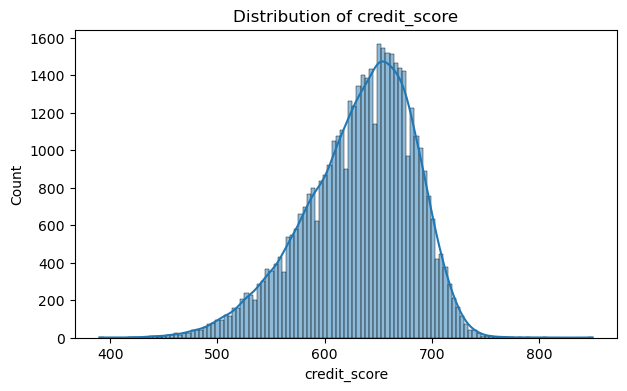

In [22]:
for col in numerical_features:
    plt.figure(figsize=(7,4))

    sns.histplot(data=df, x=col, kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

In [23]:
for column in numerical_features:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print("Min:", df[column].min())
    print("Max:", df[column].max())


person_age
Unique values: 60
Min: 20.0
Max: 144.0

person_income
Unique values: 33989
Min: 8000.0
Max: 7200766.0

person_emp_exp
Unique values: 63
Min: 0
Max: 125

loan_amnt
Unique values: 4483
Min: 500.0
Max: 35000.0

loan_int_rate
Unique values: 1302
Min: 5.42
Max: 20.0

loan_percent_income
Unique values: 64
Min: 0.0
Max: 0.66

cb_person_cred_hist_length
Unique values: 29
Min: 2.0
Max: 30.0

credit_score
Unique values: 340
Min: 390
Max: 850


In [24]:
outlier_summary = []

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) |
                (df[col] > upper_bound)).sum()

    outlier_summary.append([
        col,
        Q1,
        Q3,
        lower_bound,
        upper_bound,
        outliers
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

outlier_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,person_age,24.00,30.00,15.000,39.000,2188
1,person_income,47204.00,95789.25,-25673.875,168667.125,2218
2,person_emp_exp,1.00,8.00,-9.500,18.500,1724
3,loan_amnt,5000.00,12237.25,-5855.875,23093.125,2348
4,loan_int_rate,8.59,12.99,1.990,19.590,124
5,loan_percent_income,0.07,0.19,-0.110,0.370,744
6,cb_person_cred_hist_length,3.00,8.00,-4.500,15.500,1366
7,credit_score,601.00,670.00,497.500,773.500,467


In [25]:
df[df["person_age"] > 80][
    [
        "person_age",
        "person_emp_exp",
        "person_income",
        "loan_status"
    ]
].sort_values(
    "person_age",
    ascending=False
)

,person_age,person_emp_exp,person_income,loan_status
81,144.0,125,300616.0,0
183,144.0,121,241424.0,0
32297,144.0,124,7200766.0,0
575,123.0,101,97140.0,0
747,123.0,100,94723.0,0
37930,116.0,93,5545545.0,0
38113,109.0,85,5556399.0,0
32416,94.0,76,29738.0,0
32506,84.0,61,114705.0,0


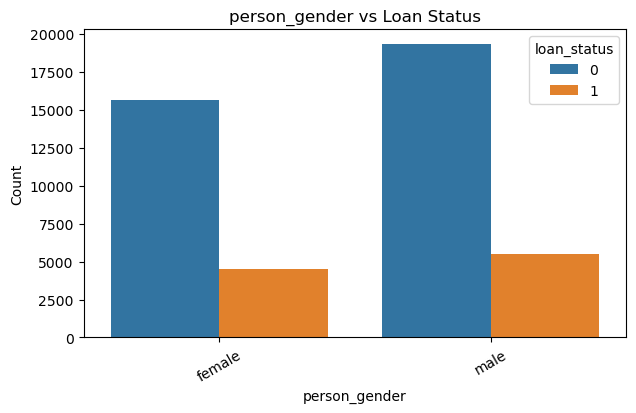

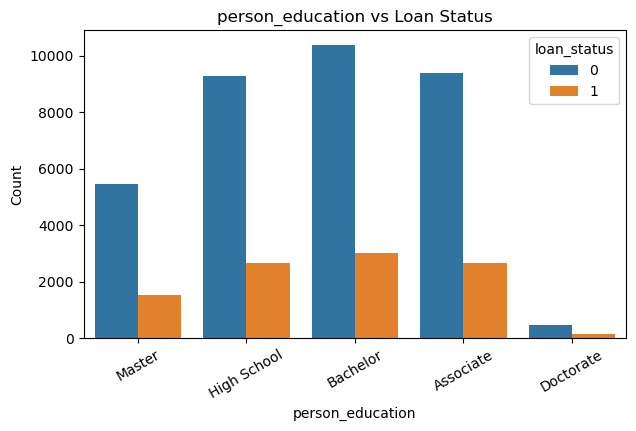

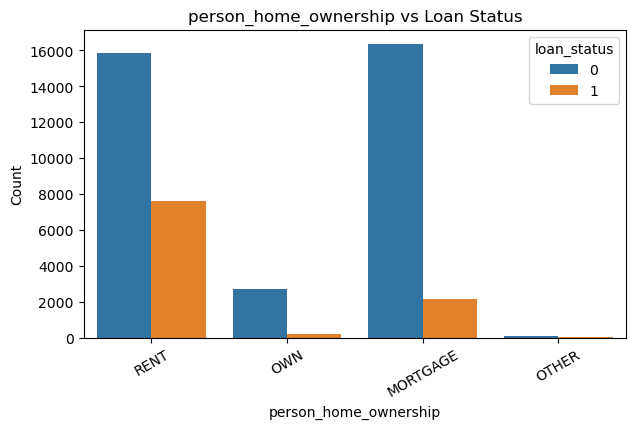

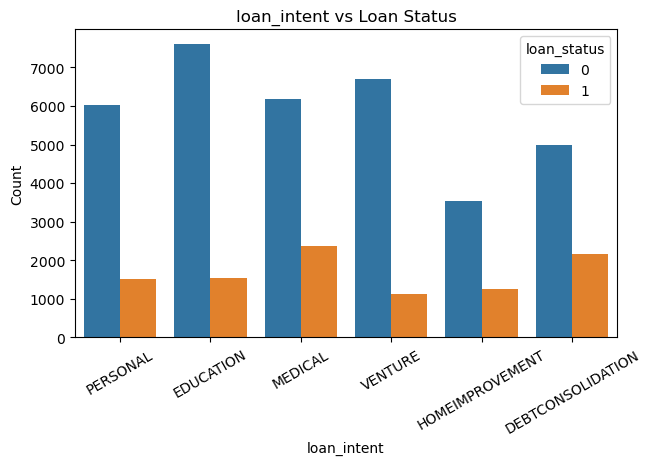

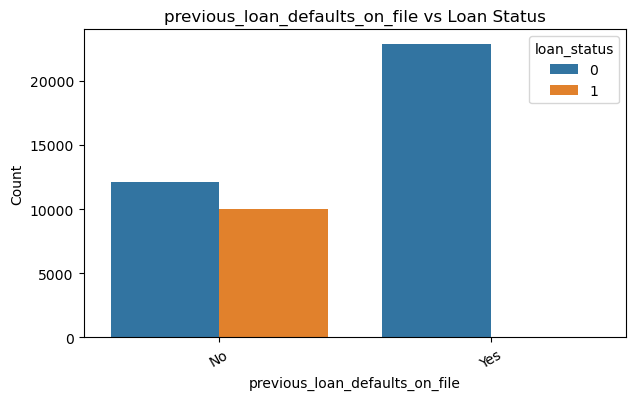

In [26]:
for column in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=column,
        hue="loan_status"
    )

    plt.title(f"{column} vs Loan Status")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=30)

    plt.show()

In [27]:
for column in categorical_features:

    print(f"\n{column}")

    result = pd.crosstab(
        df[column],
        df["loan_status"],
        normalize="index"
    ) * 100

    print(result.round(2))


person_gender
loan_status        0      1
person_gender              
female         77.75  22.25
male           77.80  22.20

person_education
loan_status           0      1
person_education              
Associate         77.97  22.03
Bachelor          77.48  22.52
Doctorate         77.13  22.87
High School       77.69  22.31
Master            78.24  21.76

person_home_ownership
loan_status                0      1
person_home_ownership              
MORTGAGE               88.40  11.60
OTHER                  66.67  33.33
OWN                    92.48   7.52
RENT                   67.60  32.40

loan_intent
loan_status            0      1
loan_intent                    
DEBTCONSOLIDATION  69.73  30.27
EDUCATION          83.04  16.96
HOMEIMPROVEMENT    73.70  26.30
MEDICAL            72.18  27.82
PERSONAL           79.86  20.14
VENTURE            85.57  14.43

previous_loan_defaults_on_file
loan_status                          0      1
previous_loan_defaults_on_file               
No    

In [28]:
df.groupby("loan_status")[numerical_features].mean().T

loan_status,0,1
person_age,27.833571,27.521300
person_income,86157.040743,59886.096900
person_emp_exp,5.476714,5.178000
loan_amnt,9219.576914,10855.689800
loan_int_rate,10.477981,12.856794
loan_percent_income,0.121783,0.202521
cb_person_cred_hist_length,5.898286,5.759700
credit_score,632.814914,631.887200


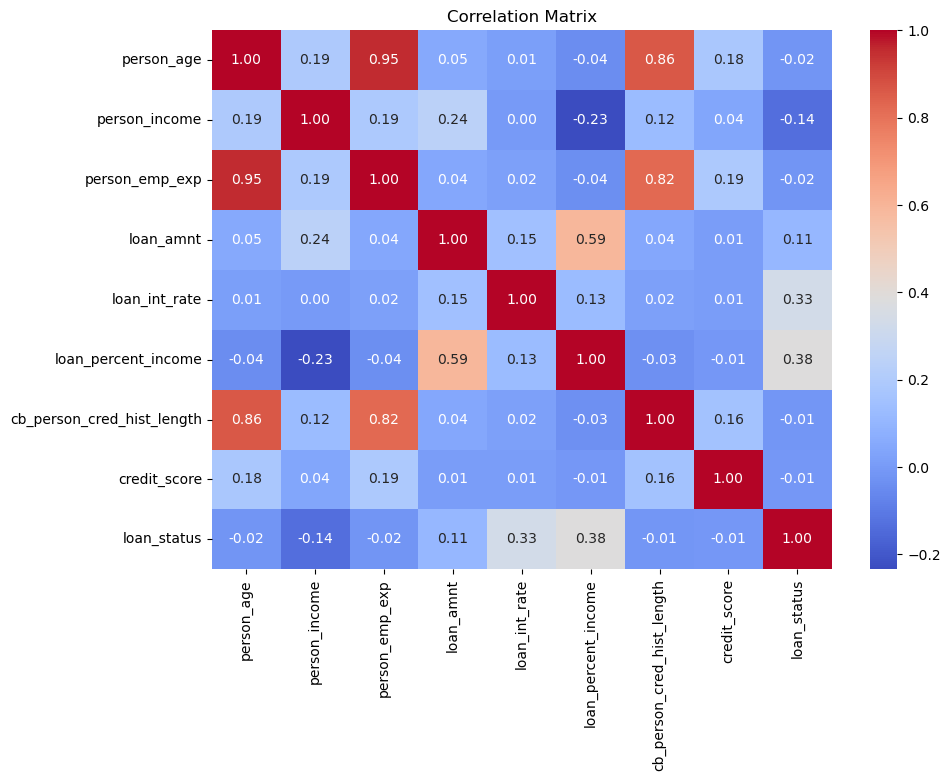

In [29]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [30]:
correlation_matrix["loan_status"].sort_values(
    ascending=False
)

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64